In [ ]:
# CELL 1 — Install and import everything we need
!pip install yfinance pandas numpy matplotlib

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

print("All libraries loaded successfully")

All libraries loaded successfully


In [ ]:
# CELL 2 — Load your movie dataset
movies = pd.read_csv('tmdb_5000_movies.csv')

# First look at what we have
print("Shape:", movies.shape)
print("\nColumns:", movies.columns.tolist())
print("\nFirst 3 rows:")
movies.head(3)

Shape: (4803, 20)

Columns: ['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']

First 3 rows:


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466


In [ ]:
# CELL 3 — Pull stock price data for all 4 studios
# This is pulling real historical data directly from Yahoo Finance

tickers = {
    "DIS": "Disney",
    "NFLX": "Netflix",
    "WBD": "Warner Bros Discovery",
    "PARA": "Paramount"
}

stock_data = yf.download(
    list(tickers.keys()),
    start="2015-01-01",
    end="2024-12-31",
    auto_adjust=True
)

# Save it
stock_data.to_csv("stock_prices_raw.csv")

print("Stock data shape:", stock_data.shape)
print("\nDate range:", stock_data.index.min(), "to", stock_data.index.max())
stock_data.tail(3)

ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: PARA"}}}
[*********************100%***********************]  4 of 4 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['PARA']: YFTzMissingError('possibly delisted; no timezone found')


Stock data shape: (2515, 21)

Date range: 2015-01-02 00:00:00 to 2024-12-30 00:00:00


Price      Adj Close       Close                               High  \
Ticker          PARA         DIS       NFLX PARA    WBD         DIS   
Date                                                                  
2024-12-26       NaN  111.318909  92.414001  NaN  10.62  112.080483   
2024-12-27       NaN  110.329849  90.754997  NaN  10.61  110.893614   
2024-12-30       NaN  109.588051  90.042999  NaN  10.51  110.319954   

Price                                     Low  ...                    Open  \
Ticker           NFLX PARA    WBD         DIS  ... PARA    WBD         DIS   
Date                                           ...                           
2024-12-26  93.049004  NaN  10.70  110.636454  ...  NaN  10.36  110.893612   
2024-12-27  91.813004  NaN  10.65  109.647394  ...  NaN  10.43  110.596893   
2024-12-30  90.822998  NaN  10.62  108.628660  ...  NaN  10.32  109.222095   

Price                               Volume                           
Ticker           NFLX PARA    WBD      DIS      NFLX PARA       WBD  
Date                                                                 
2024-12-26  92.839996  NaN  10.47  4781400  23403000  NaN  13568400  
2024-12-27  91.600998  NaN  10.52  4523800  32262000  NaN  16494400  
2024-12-30  89.450996  NaN  10.52  5716300  22030000  NaN  17814800  

[3 rows x 21 columns]

In [ ]:
# Run this to see everything
print(movies.columns.tolist())
print("\n")
print(movies.dtypes)
print("\n")
movies.head(2)

['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']


budget                    int64
genres                   object
homepage                 object
id                        int64
keywords                 object
original_language        object
original_title           object
overview                 object
popularity              float64
production_companies     object
production_countries     object
release_date             object
revenue                   int64
runtime                 float64
spoken_languages         object
status                   object
tagline                  object
title                    object
vote_average            float64
vote_count                int64
dtype: object




,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500


In [ ]:
# CELL 4 — Full Data Audit
print("=== MOVIES DATASET ===")
print("Shape:", movies.shape)
print("\nColumn Names and Data Types:")
print(movies.dtypes)
print("\nMissing Values:")
print(movies.isnull().sum())
print("\nSample of money columns:")
print(movies[['title', 'budget', 'revenue', 'release_date']].head(10))
print("\nSample production_companies column:")
print(movies['production_companies'].head(5))
print("\nSample genres column:")
print(movies['genres'].head(3))

=== MOVIES DATASET ===
Shape: (4803, 20)

Column Names and Data Types:
budget                    int64
genres                   object
homepage                 object
id                        int64
keywords                 object
original_language        object
original_title           object
overview                 object
popularity              float64
production_companies     object
production_countries     object
release_date             object
revenue                   int64
runtime                 float64
spoken_languages         object
status                   object
tagline                  object
title                    object
vote_average            float64
vote_count                int64
dtype: object

Missing Values:
budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                

In [ ]:
# CELL 5 — Drop irrelevant columns
columns_to_drop = ['homepage', 'tagline', 'keywords', 'spoken_languages',
                   'production_countries', 'original_title', 'overview', 'id']

movies_clean = movies.drop(columns=columns_to_drop)

print("Original columns:", movies.shape[1])
print("Remaining columns:", movies_clean.shape[1])
print("\nColumns kept:")
print(movies_clean.columns.tolist())

Original columns: 20
Remaining columns: 12

Columns kept:
['budget', 'genres', 'original_language', 'popularity', 'production_companies', 'release_date', 'revenue', 'runtime', 'status', 'title', 'vote_average', 'vote_count']


In [ ]:
# CELL 6 — Convert release_date from text to actual date
movies_clean['release_date'] = pd.to_datetime(movies_clean['release_date'])

# Drop the one row with missing release date
movies_clean = movies_clean.dropna(subset=['release_date'])

# Extract useful date parts you'll need later
movies_clean['release_year'] = movies_clean['release_date'].dt.year
movies_clean['release_month'] = movies_clean['release_date'].dt.month
movies_clean['release_quarter'] = movies_clean['release_date'].dt.quarter

print("release_date dtype:", movies_clean['release_date'].dtype)
print("\nYear range:", movies_clean['release_year'].min(), "to", movies_clean['release_year'].max())
print("\nSample:")
movies_clean[['title', 'release_date', 'release_year', 'release_month', 'release_quarter']].head(5)

release_date dtype: datetime64[ns]

Year range: 1916 to 2017

Sample:


,title,release_date,release_year,release_month,release_quarter
0,Avatar,2009-12-10,2009,12,4
1,Pirates of the Caribbean: At World's End,2007-05-19,2007,5,2
2,Spectre,2015-10-26,2015,10,4
3,The Dark Knight Rises,2012-07-16,2012,7,3
4,John Carter,2012-03-07,2012,3,1


In [ ]:
# CELL 7 — Identify and handle zero budget/revenue
print("Films with zero budget:", (movies_clean['budget'] == 0).sum())
print("Films with zero revenue:", (movies_clean['revenue'] == 0).sum())
print("Films with BOTH zero:", ((movies_clean['budget'] == 0) & (movies_clean['revenue'] == 0)).sum())

# Flag them first before removing
movies_clean['budget_reported'] = movies_clean['budget'] > 0
movies_clean['revenue_reported'] = movies_clean['revenue'] > 0

# Keep only films where BOTH budget and revenue are reported
movies_financial = movies_clean[
    (movies_clean['budget'] > 0) &
    (movies_clean['revenue'] > 0)
].copy()

print("\nFilms with complete financial data:", movies_financial.shape[0])
print("Films removed due to missing financials:", movies_clean.shape[0] - movies_financial.shape[0])

Films with zero budget: 1036
Films with zero revenue: 1426
Films with BOTH zero: 889

Films with complete financial data: 3229
Films removed due to missing financials: 1573


In [ ]:
# CELL 8 — Extract studio names from JSON and map to tickers
import json

# Function to extract first production company name
def extract_primary_studio(company_str):
    try:
        companies = json.loads(company_str.replace("'", '"'))
        if companies:
            return companies[0]['name']
        return None
    except:
        return None

# Apply to every row
movies_financial['primary_studio_raw'] = movies_financial['production_companies'].apply(extract_primary_studio)

# Define your studio mapping — entity resolution
studio_mapping = {
    # Disney
    'Walt Disney Pictures': 'DIS',
    'Pixar': 'DIS',
    'Marvel Studios': 'DIS',
    'Lucasfilm': 'DIS',
    'Walt Disney Animation Studios': 'DIS',
    # Netflix
    'Netflix': 'NFLX',
    # Warner Bros
    'Warner Bros. Pictures': 'WBD',
    'DC Films': 'WBD',
    'New Line Cinema': 'WBD',
    'Castle Rock Entertainment': 'WBD',
    # Paramount
    'Paramount Pictures': 'PARA',
    'Paramount Animation': 'PARA',
}

# Apply the mapping
movies_financial['ticker'] = movies_financial['primary_studio_raw'].map(studio_mapping)

# Check results
print("Studio mapping results:")
print(movies_financial['ticker'].value_counts())
print("\nUnmapped studios (showing top 10):")
print(movies_financial[movies_financial['ticker'].isna()]['primary_studio_raw'].value_counts().head(10))

Studio mapping results:
ticker
PARA    238
WBD     152
DIS     122
Name: count, dtype: int64

Unmapped studios (showing top 10):
primary_studio_raw
Universal Pictures                        227
Columbia Pictures                         166
Twentieth Century Fox Film Corporation    152
Village Roadshow Pictures                  62
United Artists                             61
Miramax Films                              60
Columbia Pictures Corporation              57
Warner Bros.                               54
DreamWorks SKG                             54
Fox Searchlight Pictures                   43
Name: count, dtype: int64


In [ ]:
# CELL 9 — Extract primary genre and calculate ROI
# Extract primary genre
def extract_primary_genre(genre_str):
    try:
        genres = json.loads(genre_str.replace("'", '"'))
        if genres:
            return genres[0]['name']
        return 'Unknown'
    except:
        return 'Unknown'

movies_financial['primary_genre'] = movies_financial['genres'].apply(extract_primary_genre)

# Calculate ROI — your most important metric
movies_financial['ROI'] = (
    (movies_financial['revenue'] - movies_financial['budget']) / movies_financial['budget']
) * 100

# Calculate budget tier — a business segmentation variable
movies_financial['budget_tier'] = pd.cut(
    movies_financial['budget'],
    bins=[0, 50000000, 150000000, 250000000, float('inf')],
    labels=['Low (<$50M)', 'Mid ($50M-$150M)', 'High ($150M-$250M)', 'Mega (>$250M)']
)

# Final check
print("Primary genres found:")
print(movies_financial['primary_genre'].value_counts().head(10))
print("\nBudget tiers:")
print(movies_financial['budget_tier'].value_counts())
print("\nROI summary:")
print(movies_financial['ROI'].describe())
print("\nFinal clean dataset shape:", movies_financial.shape)

Primary genres found:
primary_genre
Drama              747
Comedy             634
Action             588
Adventure          288
Horror             197
Crime              141
Thriller           118
Animation           99
Fantasy             93
Science Fiction     79
Name: count, dtype: int64

Budget tiers:
budget_tier
Low (<$50M)           2372
Mid ($50M-$150M)       754
High ($150M-$250M)      95
Mega (>$250M)            8
Name: count, dtype: int64

ROI summary:
count    3.229000e+03
mean     2.953822e+05
std      1.506101e+07
min     -9.999995e+01
25%      2.246328e+00
50%      1.300366e+02
75%      3.420822e+02
max      8.499999e+08
Name: ROI, dtype: float64

Final clean dataset shape: (3229, 22)


In [ ]:
# Quick ticker check
print("Films mapped to tickers:")
print(movies_financial['ticker'].value_counts())
print("\nTotal mapped:", movies_financial['ticker'].notna().sum())
print("Total unmapped:", movies_financial['ticker'].isna().sum())

Films mapped to tickers:
ticker
PARA    238
WBD     152
DIS     122
Name: count, dtype: int64

Total mapped: 512
Total unmapped: 2717


In [ ]:
# CELL 10 — Improve Disney mapping and filter to target studios

# Secondary studio check for Disney — catches Marvel/Pixar listed as primary
def map_ticker_improved(row):
    # If already mapped, keep it
    if pd.notna(row['ticker']):
        return row['ticker']

    # Check full production companies string for Disney subsidiaries
    companies_str = str(row['production_companies'])

    disney_keywords = ['Walt Disney', 'Pixar', 'Marvel Studios',
                      'Lucasfilm', 'Disney Animation']
    warner_keywords = ['Warner Bros', 'DC Films', 'New Line Cinema']
    paramount_keywords = ['Paramount']
    netflix_keywords = ['Netflix']

    for keyword in disney_keywords:
        if keyword in companies_str:
            return 'DIS'
    for keyword in warner_keywords:
        if keyword in companies_str:
            return 'WBD'
    for keyword in paramount_keywords:
        if keyword in companies_str:
            return 'PARA'
    for keyword in netflix_keywords:
        if keyword in companies_str:
            return 'NFLX'

    return None

# Apply improved mapping
movies_financial['ticker'] = movies_financial.apply(map_ticker_improved, axis=1)

print("Improved ticker mapping:")
print(movies_financial['ticker'].value_counts())
print("\nTotal mapped:", movies_financial['ticker'].notna().sum())

Improved ticker mapping:
ticker
WBD     437
PARA    257
DIS     145
Name: count, dtype: int64

Total mapped: 839


In [ ]:
# CELL 11 — Filter to your studios and handle ROI outliers

studio_films = movies_financial[
    movies_financial['ticker'].isin(['DIS', 'WBD', 'PARA'])
].copy()

print("Films per studio after improved mapping:")
print(studio_films['ticker'].value_counts())

# Handle ROI outliers using IQR method
Q1 = studio_films['ROI'].quantile(0.25)
Q3 = studio_films['ROI'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nROI outlier bounds:")
print(f"Lower: {lower_bound:.1f}%")
print(f"Upper: {upper_bound:.1f}%")

studio_films['ROI_capped'] = studio_films['ROI'].clip(
    lower=lower_bound,
    upper=upper_bound
)

print(f"\nROI before capping - Mean: {studio_films['ROI'].mean():.1f}%, Median: {studio_films['ROI'].median():.1f}%")
print(f"ROI after capping  - Mean: {studio_films['ROI_capped'].mean():.1f}%, Median: {studio_films['ROI_capped'].median():.1f}%")
print(f"\nFinal studio dataset shape: {studio_films.shape}")

Films per studio after improved mapping:
ticker
WBD     437
PARA    257
DIS     145
Name: count, dtype: int64

ROI outlier bounds:
Lower: -455.2%
Upper: 824.4%

ROI before capping - Mean: 515.8%, Median: 153.3%
ROI after capping  - Mean: 230.9%, Median: 153.3%

Final studio dataset shape: (839, 23)


In [ ]:
# Pre-Cell 12 — Look at your raw stock data structure
print("Stock data shape:", stock_data.shape)
print("\nColumn structure:")
print(stock_data.columns)
print("\nFirst 5 rows:")
stock_data.head()
print("\nMissing values:")
print(stock_data.isnull().sum())

Stock data shape: (2515, 21)

Column structure:
MultiIndex([('Adj Close', 'PARA'),
            (    'Close',  'DIS'),
            (    'Close', 'NFLX'),
            (    'Close', 'PARA'),
            (    'Close',  'WBD'),
            (     'High',  'DIS'),
            (     'High', 'NFLX'),
            (     'High', 'PARA'),
            (     'High',  'WBD'),
            (      'Low',  'DIS'),
            (      'Low', 'NFLX'),
            (      'Low', 'PARA'),
            (      'Low',  'WBD'),
            (     'Open',  'DIS'),
            (     'Open', 'NFLX'),
            (     'Open', 'PARA'),
            (     'Open',  'WBD'),
            (   'Volume',  'DIS'),
            (   'Volume', 'NFLX'),
            (   'Volume', 'PARA'),
            (   'Volume',  'WBD')],
           names=['Price', 'Ticker'])

First 5 rows:

Missing values:
Price      Ticker
Adj Close  PARA      2515
Close      DIS          0
           NFLX         0
           PARA      2515
           WBD          

In [ ]:
# CELL 12 — Re-pull stock data with corrected Paramount tickers

# Pull Disney, Netflix, Warner Bros as before
main_stocks = yf.download(
    ['DIS', 'NFLX', 'WBD'],
    start="2015-01-01",
    end="2024-12-31",
    auto_adjust=True
)

# Pull VIAC (old Paramount) separately
viac_stock = yf.download(
    'VIAC',
    start="2015-01-01",
    end="2022-02-15",
    auto_adjust=True
)

# Pull PARA (new Paramount) separately
para_stock = yf.download(
    'PARA',
    start="2022-02-16",
    end="2024-12-31",
    auto_adjust=True
)

print("Main stocks shape:", main_stocks.shape)
print("VIAC shape:", viac_stock.shape)
print("PARA shape:", para_stock.shape)
print("\nVIAC date range:", viac_stock.index.min(), "to", viac_stock.index.max())
print("PARA date range:", para_stock.index.min(), "to", para_stock.index.max())

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['VIAC']: YFTzMissingError('possibly delisted; no timezone found')
[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['PARA']: YFTzMissingError('possibly delisted; no timezone found')


Main stocks shape: (2515, 15)
VIAC shape: (0, 6)
PARA shape: (0, 6)

VIAC date range: NaT to NaT
PARA date range: NaT to NaT


In [ ]:
# CELL 13 — Flatten MultiIndex and extract closing prices

# Extract Close prices from main stocks
dis_close = main_stocks['Close']['DIS'].rename('DIS')
nflx_close = main_stocks['Close']['NFLX'].rename('NFLX')
wbd_close = main_stocks['Close']['WBD'].rename('WBD')

# Extract Close prices from Paramount series
# Handle both single and multi-ticker download structures
if isinstance(viac_stock.columns, pd.MultiIndex):
    viac_close = viac_stock['Close']['VIAC'].rename('PARA')
else:
    viac_close = viac_stock['Close'].rename('PARA')

if isinstance(para_stock.columns, pd.MultiIndex):
    para_close = para_stock['Close']['PARA'].rename('PARA')
else:
    para_close = para_stock['Close'].rename('PARA')

# Splice VIAC and PARA into one continuous Paramount series
para_combined = pd.concat([viac_close, para_close])
para_combined = para_combined[~para_combined.index.duplicated(keep='last')]
para_combined = para_combined.sort_index()

# Combine all four into one clean dataframe
stocks_clean = pd.concat([dis_close, nflx_close, wbd_close, para_combined], axis=1)
stocks_clean.columns = ['DIS', 'NFLX', 'WBD', 'PARA']

print("Clean stocks shape:", stocks_clean.shape)
print("\nDate range:", stocks_clean.index.min(), "to", stocks_clean.index.max())
print("\nMissing values per ticker:")
print(stocks_clean.isnull().sum())
print("\nFirst 5 rows:")
print(stocks_clean.head())
print("\nSample around merger date:")
print(stocks_clean.loc['2022-02-10':'2022-02-20'])

Clean stocks shape: (2515, 4)

Date range: 2015-01-02 00:00:00 to 2024-12-30 00:00:00

Missing values per ticker:
DIS        0
NFLX       0
WBD        0
PARA    2515
dtype: int64

First 5 rows:
                  DIS      NFLX        WBD  PARA
Date                                            
2015-01-02  85.365936  4.984857  34.480000   NaN
2015-01-05  84.118462  4.731143  33.060001   NaN
2015-01-06  83.672264  4.650143  31.980000   NaN
2015-01-07  84.528229  4.674286  32.209999   NaN
2015-01-08  85.402344  4.778000  32.470001   NaN

Sample around merger date:
                   DIS       NFLX        WBD  PARA
Date                                              
2022-02-10  148.659180  40.626999  30.090000   NaN
2022-02-11  146.031082  39.131001  29.570000   NaN
2022-02-14  147.379318  39.657001  29.420000   NaN
2022-02-15  151.160278  40.745998  30.510000   NaN
2022-02-16  152.752747  39.807999  29.379999   NaN
2022-02-17  149.430984  38.667000  29.870001   NaN
2022-02-18  147.877563  39.

In [ ]:
# CELL 14 — Calculate daily returns and pull market benchmark

# Calculate daily percentage return for each studio
# Formula: (today's price - yesterday's price) / yesterday's price * 100
returns = stocks_clean.pct_change() * 100
returns.columns = ['DIS_return', 'NFLX_return', 'WBD_return', 'PARA_return']

# Pull S&P 500 as your market benchmark
sp500 = yf.download('^GSPC', start="2015-01-01", end="2024-12-31", auto_adjust=True)

# Extract S&P 500 daily return
if isinstance(sp500.columns, pd.MultiIndex):
    sp500_return = sp500['Close']['^GSPC'].pct_change() * 100
else:
    sp500_return = sp500['Close'].pct_change() * 100

sp500_return.name = 'SP500_return'

# Combine returns with S&P 500
returns_full = pd.concat([returns, sp500_return], axis=1)

# Calculate abnormal returns for each studio
# Abnormal return = studio return - market return
returns_full['DIS_abnormal'] = returns_full['DIS_return'] - returns_full['SP500_return']
returns_full['NFLX_abnormal'] = returns_full['NFLX_return'] - returns_full['SP500_return']
returns_full['WBD_abnormal'] = returns_full['WBD_return'] - returns_full['SP500_return']
returns_full['PARA_abnormal'] = returns_full['PARA_return'] - returns_full['SP500_return']

# Drop the first row — it will always be NaN because there's no previous day to compare
returns_full = returns_full.dropna(how='all')

print("Returns dataframe shape:", returns_full.shape)
print("\nColumns:", returns_full.columns.tolist())
print("\nSample returns:")
print(returns_full.head())
print("\nReturn statistics:")
print(returns_full[['DIS_return', 'WBD_return', 'PARA_return']].describe().round(2))

/tmp/ipykernel_3426/4083615726.py:5: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = stocks_clean.pct_change() * 100
[*********************100%***********************]  1 of 1 completed

Returns dataframe shape: (2514, 9)

Columns: ['DIS_return', 'NFLX_return', 'WBD_return', 'PARA_return', 'SP500_return', 'DIS_abnormal', 'NFLX_abnormal', 'WBD_abnormal', 'PARA_abnormal']

Sample returns:
            DIS_return  NFLX_return  WBD_return  PARA_return  SP500_return  \
Date                                                                         
2015-01-05   -1.461326    -5.089696   -4.118324          NaN     -1.827811   
2015-01-06   -0.530439    -1.712057   -3.266793          NaN     -0.889347   
2015-01-07    1.022997     0.519183    0.719198          NaN      1.162984   
2015-01-08    1.034110     2.218820    0.807209          NaN      1.788828   
2015-01-09    0.490483    -1.545769   -1.355104          NaN     -0.840381   

            DIS_abnormal  NFLX_abnormal  WBD_abnormal  PARA_abnormal  
Date                                                                  
2015-01-05      0.366484      -3.261886     -2.290514            NaN  
2015-01-06      0.358908      -0.8227

In [ ]:
# DIAGNOSTIC — Check what actually came back for VIAC and PARA
print("=== VIAC DATA ===")
print("Shape:", viac_stock.shape)
print("Columns:", viac_stock.columns.tolist())
print("First 3 rows:")
print(viac_stock.head(3))

print("\n=== PARA DATA ===")
print("Shape:", para_stock.shape)
print("Columns:", para_stock.columns.tolist())
print("First 3 rows:")
print(para_stock.head(3))

print("\n=== COMBINED PARA SERIES ===")
print("Shape:", para_combined.shape)
print("Missing values:", para_combined.isnull().sum())
print("First 3 rows:")
print(para_combined.head(3))
print("Last 3 rows:")
print(para_combined.tail(3))

=== VIAC DATA ===
Shape: (0, 6)
Columns: [('Adj Close', 'VIAC'), ('Close', 'VIAC'), ('High', 'VIAC'), ('Low', 'VIAC'), ('Open', 'VIAC'), ('Volume', 'VIAC')]
First 3 rows:
Empty DataFrame
Columns: [(Adj Close, VIAC), (Close, VIAC), (High, VIAC), (Low, VIAC), (Open, VIAC), (Volume, VIAC)]
Index: []

=== PARA DATA ===
Shape: (0, 6)
Columns: [('Adj Close', 'PARA'), ('Close', 'PARA'), ('High', 'PARA'), ('Low', 'PARA'), ('Open', 'PARA'), ('Volume', 'PARA')]
First 3 rows:
Empty DataFrame
Columns: [(Adj Close, PARA), (Close, PARA), (High, PARA), (Low, PARA), (Open, PARA), (Volume, PARA)]
Index: []

=== COMBINED PARA SERIES ===
Shape: (0,)
Missing values: 0
First 3 rows:
Series([], Name: PARA, dtype: float64)
Last 3 rows:
Series([], Name: PARA, dtype: float64)


In [ ]:
# DIAGNOSTIC — Test all possible Paramount ticker variations
test_tickers = ['PARA', 'VIAC', 'VIACA', 'VIACP', 'CBS', 'VIA', 'PARAA']

for ticker in test_tickers:
    try:
        test = yf.download(ticker, start="2020-01-01", end="2023-01-01",
                          auto_adjust=True, progress=False)
        if len(test) > 0:
            print(f"✓ {ticker} — {len(test)} rows — "
                  f"{test.index.min().date()} to {test.index.max().date()}")
        else:
            print(f"✗ {ticker} — empty")
    except Exception as e:
        print(f"✗ {ticker} — error: {e}")

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['PARA']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['VIAC']: YFTzMissingError('possibly delisted; no timezone found')


✗ PARA — empty
✗ VIAC — empty


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['VIACA']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['VIACP']: YFTzMissingError('possibly delisted; no timezone found')


✗ VIACA — empty
✗ VIACP — empty


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['CBS']: YFTzMissingError('possibly delisted; no timezone found')


✗ CBS — empty


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['VIA']: YFPricesMissingError('possibly delisted; no price data found  (1d 2020-01-01 -> 2023-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1577854800, endDate = 1672549200")')


✗ VIA — empty


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['PARAA']: YFTzMissingError('possibly delisted; no timezone found')


✗ PARAA — empty


In [ ]:
# CELL 15 — Re-pull all stock data with Sony replacing Paramount

# Pull all three studios in one download
stocks_raw = yf.download(
    ['DIS', 'WBD', 'SONY'],
    start="2015-01-01",
    end="2024-12-31",
    auto_adjust=True
)

print("Raw download shape:", stocks_raw.shape)
print("\nColumn structure:")
print(stocks_raw.columns.tolist())
print("\nMissing values:")
print(stocks_raw.isnull().sum())

[*********************100%***********************]  3 of 3 completed

Raw download shape: (2515, 15)

Column structure:
[('Close', 'DIS'), ('Close', 'SONY'), ('Close', 'WBD'), ('High', 'DIS'), ('High', 'SONY'), ('High', 'WBD'), ('Low', 'DIS'), ('Low', 'SONY'), ('Low', 'WBD'), ('Open', 'DIS'), ('Open', 'SONY'), ('Open', 'WBD'), ('Volume', 'DIS'), ('Volume', 'SONY'), ('Volume', 'WBD')]

Missing values:
Price   Ticker
Close   DIS       0
        SONY      0
        WBD       0
High    DIS       0
        SONY      0
        WBD       0
Low     DIS       0
        SONY      0
        WBD       0
Open    DIS       0
        SONY      0
        WBD       0
Volume  DIS       0
        SONY      0
        WBD       0
dtype: int64


In [ ]:
# Update studio mapping to replace PARA with SONY
sony_keywords = ['Sony Pictures', 'Columbia Pictures', 'TriStar Pictures',
                 'Screen Gems', 'Sony Pictures Animation']

def map_ticker_with_sony(row):
    companies_str = str(row['production_companies'])

    disney_keywords = ['Walt Disney', 'Pixar', 'Marvel Studios',
                      'Lucasfilm', 'Disney Animation']
    warner_keywords = ['Warner Bros', 'DC Films', 'New Line Cinema']
    sony_keywords_list = ['Sony Pictures', 'Columbia Pictures',
                         'TriStar Pictures', 'Screen Gems',
                         'Sony Pictures Animation']

    for keyword in disney_keywords:
        if keyword in companies_str:
            return 'DIS'
    for keyword in warner_keywords:
        if keyword in companies_str:
            return 'WBD'
    for keyword in sony_keywords_list:
        if keyword in companies_str:
            return 'SONY'

    return None

# Re-apply mapping to full financial dataset
movies_financial['ticker'] = movies_financial.apply(
    map_ticker_with_sony, axis=1
)

# Filter to three studios
studio_films = movies_financial[
    movies_financial['ticker'].isin(['DIS', 'WBD', 'SONY'])
].copy()

# Re-apply ROI capping
Q1 = studio_films['ROI'].quantile(0.25)
Q3 = studio_films['ROI'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
studio_films['ROI_capped'] = studio_films['ROI'].clip(
    lower=lower_bound,
    upper=upper_bound
)

print("Updated studio film counts:")
print(studio_films['ticker'].value_counts())
print("\nFinal dataset shape:", studio_films.shape)
print("\nROI summary by studio:")
print(studio_films.groupby('ticker')['ROI_capped'].describe().round(1))

Updated studio film counts:
ticker
WBD     427
SONY    339
DIS     147
Name: count, dtype: int64

Final dataset shape: (913, 23)

ROI summary by studio:
        count   mean    std   min   25%    50%    75%    max
ticker                                                      
DIS     147.0  283.8  254.2 -84.3  84.4  221.6  433.2  761.2
SONY    339.0  201.9  229.9 -99.6  36.9  136.5  292.8  761.2
WBD     427.0  196.6  243.7 -98.5  10.5  121.8  284.6  761.2


In [ ]:
# CELL 18 — Build event study window function

# First make sure returns_full index is datetime
returns_full.index = pd.to_datetime(returns_full.index)

# Make sure studio_films release_date is datetime
studio_films['release_date'] = pd.to_datetime(studio_films['release_date'])

# Filter studio films to match your stock data date range
stock_start = returns_full.index.min()
stock_end = returns_full.index.max()

studio_films_filtered = studio_films[
    (studio_films['release_date'] >= stock_start) &
    (studio_films['release_date'] <= stock_end)
].copy()

print("Films within stock data date range:", len(studio_films_filtered))
print("Films outside range (excluded):", len(studio_films) - len(studio_films_filtered))
print("\nDate range of filtered films:")
print("Earliest:", studio_films_filtered['release_date'].min())
print("Latest:", studio_films_filtered['release_date'].max())
print("\nFilms per studio after date filter:")
print(studio_films_filtered['ticker'].value_counts())

Films within stock data date range: 52
Films outside range (excluded): 861

Date range of filtered films:
Earliest: 2015-02-04 00:00:00
Latest: 2016-08-10 00:00:00

Films per studio after date filter:
ticker
WBD     23
SONY    17
DIS     12
Name: count, dtype: int64


In [ ]:
# DIAGNOSTIC — Understand the date problem

print("=== STOCK DATA DATE RANGE ===")
print("Start:", returns_full.index.min())
print("End:", returns_full.index.max())
print("Type:", type(returns_full.index[0]))

print("\n=== STUDIO FILMS DATE RANGE ===")
print("Start:", studio_films['release_date'].min())
print("End:", studio_films['release_date'].max())
print("Type:", studio_films['release_date'].dtype)

print("\n=== RELEASE YEAR DISTRIBUTION ===")
print(studio_films['release_year'].value_counts().sort_index())

print("\n=== SAMPLE RELEASE DATES ===")
print(studio_films[['title', 'release_date', 'ticker']].head(20))

=== STOCK DATA DATE RANGE ===
Start: 2015-01-05 00:00:00
End: 2024-12-30 00:00:00
Type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>

=== STUDIO FILMS DATE RANGE ===
Start: 1933-02-02 00:00:00
End: 2016-08-10 00:00:00
Type: datetime64[ns]

=== RELEASE YEAR DISTRIBUTION ===
release_year
1933     1
1934     1
1936     1
1937     1
1938     1
        ..
2012    26
2013    36
2014    39
2015    30
2016    22
Name: count, Length: 64, dtype: int64

=== SAMPLE RELEASE DATES ===
                                          title release_date ticker
1      Pirates of the Caribbean: At World's End   2007-05-19    DIS
2                                       Spectre   2015-10-26   SONY
3                         The Dark Knight Rises   2012-07-16    WBD
4                                   John Carter   2012-03-07    DIS
5                                  Spider-Man 3   2007-05-01   SONY
6                                       Tangled   2010-11-24    DIS
7                       Avengers: Age of U

In [ ]:
# API KEY CELL — Run this first, never share this cell
TMDB_API_KEY = "bc31d41565d5dbe49f20043943a298c6"

# Verify it works
import requests
test = requests.get(
    f"https://api.themoviedb.org/3/configuration",
    params={"api_key": TMDB_API_KEY}
)
print("API Status:", test.status_code)
print("Connection:", "SUCCESS" if test.status_code == 200 else "FAILED — check your key")

API Status: 200
Connection: SUCCESS


In [ ]:
import requests
import pandas as pd
import time

# TMDB Production Company IDs — these are TMDB's internal IDs
# We use these to filter films by studio directly from the API
STUDIO_IDS = {
    'DIS': [2, 3, 4, 6125, 1, 9195, 420],      # Walt Disney, Pixar, Marvel, Lucasfilm, Disney Animation
    'WBD': [174, 128064, 12, 923, 7528],          # Warner Bros, DC Films, New Line, Legendary, Castle Rock
    'SONY': [5, 34, 2251, 7295, 3287]             # Columbia, TriStar, Sony Pictures, Screen Gems, Sony Animation
}

def pull_studio_films(studio_ticker, company_ids, api_key,
                      start_year=2015, end_year=2024):
    """
    Pull all films for a studio from TMDB API
    filtered by date range and minimum data quality
    """
    all_films = []

    for company_id in company_ids:
        print(f"\nPulling {studio_ticker} — Company ID {company_id}...")
        page = 1
        total_pages = 1

        while page <= total_pages:
            try:
                response = requests.get(
                    "https://api.themoviedb.org/3/discover/movie",
                    params={
                        "api_key": api_key,
                        "with_companies": company_id,
                        "primary_release_date.gte": f"{start_year}-01-01",
                        "primary_release_date.lte": f"{end_year}-12-31",
                        "with_original_language": "en",
                        "sort_by": "release_date.asc",
                        "page": page
                    }
                )

                data = response.json()
                total_pages = min(data.get('total_pages', 1), 500)
                results = data.get('results', [])

                for film in results:
                    all_films.append({
                        'tmdb_id': film.get('id'),
                        'title': film.get('title'),
                        'release_date': film.get('release_date'),
                        'ticker': studio_ticker,
                        'company_id': company_id,
                        'popularity': film.get('popularity'),
                        'vote_average': film.get('vote_average'),
                        'vote_count': film.get('vote_count'),
                    })

                page += 1
                time.sleep(0.25)  # Rate limiting — be respectful to the API

            except Exception as e:
                print(f"Error on page {page}: {e}")
                break

        print(f"  Found {len(all_films)} films so far")

    return all_films

# Pull all three studios
all_films = []

for ticker, company_ids in STUDIO_IDS.items():
    films = pull_studio_films(ticker, company_ids, TMDB_API_KEY)
    all_films.extend(films)
    print(f"\n{ticker} pull complete")

# Build initial dataframe
films_raw = pd.DataFrame(all_films)

print("\n=== INITIAL PULL COMPLETE ===")
print("Total records pulled:", len(films_raw))
print("\nPer studio:")
print(films_raw['ticker'].value_counts())
print("\nSample:")
print(films_raw[['title', 'release_date', 'ticker']].head(10))


Pulling DIS — Company ID 2...
  Found 81 films so far

Pulling DIS — Company ID 3...
  Found 137 films so far

Pulling DIS — Company ID 4...
  Found 244 films so far

Pulling DIS — Company ID 6125...
  Found 281 films so far

Pulling DIS — Company ID 1...
  Found 307 films so far

Pulling DIS — Company ID 9195...
  Found 307 films so far

Pulling DIS — Company ID 420...
  Found 367 films so far

DIS pull complete

Pulling WBD — Company ID 174...
  Found 109 films so far

Pulling WBD — Company ID 128064...
  Found 126 films so far

Pulling WBD — Company ID 12...
  Found 185 films so far

Pulling WBD — Company ID 923...
  Found 214 films so far

Pulling WBD — Company ID 7528...
  Found 214 films so far

WBD pull complete

Pulling SONY — Company ID 5...
  Found 94 films so far

Pulling SONY — Company ID 34...
  Found 114 films so far

Pulling SONY — Company ID 2251...
  Found 140 films so far

Pulling SONY — Company ID 7295...
  Found 147 films so far

Pulling SONY — Company ID 3287...
 

In [ ]:
def get_film_financials(tmdb_id, api_key):
    """
    Pull budget, revenue, runtime, and genres
    for a single film using its TMDB ID
    """
    try:
        response = requests.get(
            f"https://api.themoviedb.org/3/movie/{tmdb_id}",
            params={"api_key": api_key}
        )
        data = response.json()

        # Extract genres — first one is primary
        genres = data.get('genres', [])
        primary_genre = genres[0]['name'] if genres else 'Unknown'

        # Extract production companies for verification
        companies = data.get('production_companies', [])
        company_names = [c['name'] for c in companies]

        return {
            'tmdb_id': tmdb_id,
            'budget': data.get('budget', 0),
            'revenue': data.get('revenue', 0),
            'runtime': data.get('runtime', 0),
            'primary_genre': primary_genre,
            'status': data.get('status', ''),
            'production_companies': str(company_names)
        }

    except Exception as e:
        return {
            'tmdb_id': tmdb_id,
            'budget': 0,
            'revenue': 0,
            'runtime': 0,
            'primary_genre': 'Unknown',
            'status': 'Error',
            'production_companies': ''
        }

# Pull financials for every film
print(f"Pulling financials for {len(films_raw)} films...")
print("This will take a few minutes — please wait\n")

financials = []
for i, tmdb_id in enumerate(films_raw['tmdb_id']):
    financial_data = get_film_financials(tmdb_id, TMDB_API_KEY)
    financials.append(financial_data)
    time.sleep(0.25)  # Rate limiting

    # Progress update every 50 films
    if (i + 1) % 50 == 0:
        print(f"Progress: {i + 1}/{len(films_raw)} films processed")

# Build financials dataframe
financials_df = pd.DataFrame(financials)

# Merge with your base films dataframe
films_enriched = films_raw.merge(financials_df, on='tmdb_id', how='left')

print("\n=== FINANCIAL PULL COMPLETE ===")
print("Total films enriched:", len(films_enriched))
print("\nFilms with budget reported:", (films_enriched['budget'] > 0).sum())
print("Films with revenue reported:", (films_enriched['revenue'] > 0).sum())
print("Films with BOTH reported:",
      ((films_enriched['budget'] > 0) &
       (films_enriched['revenue'] > 0)).sum())
print("\nSample with financials:")
print(films_enriched[['title', 'ticker', 'release_date',
                        'budget', 'revenue',
                        'primary_genre']].head(10))

Pulling financials for 757 films...
This will take a few minutes — please wait

Progress: 50/757 films processed
Progress: 100/757 films processed
Progress: 150/757 films processed
Progress: 200/757 films processed
Progress: 250/757 films processed
Progress: 300/757 films processed
Progress: 350/757 films processed
Progress: 400/757 films processed
Progress: 450/757 films processed
Progress: 500/757 films processed
Progress: 550/757 films processed
Progress: 600/757 films processed
Progress: 650/757 films processed
Progress: 700/757 films processed
Progress: 750/757 films processed

=== FINANCIAL PULL COMPLETE ===
Total films enriched: 881

Films with budget reported: 548
Films with revenue reported: 520
Films with BOTH reported: 508

Sample with financials:
                                               title ticker release_date  \
0                                     Tick Tock Tale    DIS   2015-08-18   
1                                     Tick Tock Tale    DIS   2015-08-18   
2  

In [ ]:
# CELL — Deduplicate and clean enriched dataset

# Step 1 — Remove duplicate films
# Keep the first occurrence of each film per studio
films_deduped = films_enriched.drop_duplicates(
    subset=['tmdb_id', 'ticker'],
    keep='first'
).copy()

print("Before deduplication:", len(films_enriched))
print("After deduplication:", len(films_deduped))
print("\nPer studio after dedup:")
print(films_deduped['ticker'].value_counts())

# Step 2 — Convert release_date to datetime
films_deduped['release_date'] = pd.to_datetime(films_deduped['release_date'])

# Step 3 — Extract date parts
films_deduped['release_year'] = films_deduped['release_date'].dt.year
films_deduped['release_month'] = films_deduped['release_date'].dt.month
films_deduped['release_quarter'] = films_deduped['release_date'].dt.quarter

# Step 4 — Filter to released films with complete financials only
films_clean = films_deduped[
    (films_deduped['budget'] > 0) &
    (films_deduped['revenue'] > 0) &
    (films_deduped['status'] == 'Released')
].copy()

print("\nAfter financial filter:", len(films_clean))
print("\nPer studio with complete financials:")
print(films_clean['ticker'].value_counts())

# Step 5 — Calculate ROI
films_clean['ROI'] = (
    (films_clean['revenue'] - films_clean['budget']) /
    films_clean['budget']
) * 100

# Step 6 — Budget tiers
films_clean['budget_tier'] = pd.cut(
    films_clean['budget'],
    bins=[0, 50000000, 150000000, 250000000, float('inf')],
    labels=['Low (<$50M)', 'Mid ($50M-$150M)',
            'High ($150M-$250M)', 'Mega (>$250M)']
)

# Step 7 — Cap ROI outliers
Q1 = films_clean['ROI'].quantile(0.25)
Q3 = films_clean['ROI'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
films_clean['ROI_capped'] = films_clean['ROI'].clip(
    lower=lower_bound,
    upper=upper_bound
)

# Step 8 — Drop rows with missing runtime or vote data
films_clean = films_clean[films_clean['vote_count'] >= 10].copy()

print("\nFinal clean dataset:", len(films_clean), "films")
print("\nROI summary by studio:")
print(films_clean.groupby('ticker')['ROI_capped'].describe().round(1))
print("\nBudget tier distribution:")
print(films_clean['budget_tier'].value_counts())
print("\nTop genres:")
print(films_clean['primary_genre'].value_counts().head(8))

# Step 9 — Save to Google Drive immediately
films_clean.to_csv('/content/drive/MyDrive/films_clean.csv', index=False)
print("\nSaved to Google Drive")

Before deduplication: 881
After deduplication: 702

Per studio after dedup:
ticker
DIS     356
WBD     194
SONY    152
Name: count, dtype: int64

After financial filter: 398

Per studio with complete financials:
ticker
DIS     150
WBD     140
SONY    108
Name: count, dtype: int64

Final clean dataset: 397 films

ROI summary by studio:
        count   mean    std   min   25%    50%    75%    max
ticker                                                      
DIS     149.0  227.6  237.6 -99.4  37.9  165.8  376.2  847.6
SONY    108.0  249.1  246.3 -87.2  71.5  176.9  383.1  847.6
WBD     140.0  222.9  264.4 -84.5  15.3  148.3  322.9  847.6

Budget tier distribution:
budget_tier
Low (<$50M)           175
Mid ($50M-$150M)      125
High ($150M-$250M)     86
Mega (>$250M)          11
Name: count, dtype: int64

Top genres:
primary_genre
Action             104
Comedy              51
Horror              45
Adventure           42
Drama               36
Animation           27
Science Fiction     25
F

OSError: Cannot save file into a non-existent directory: '/content/drive/MyDrive'

In [ ]:
# Mount Google Drive first
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Save everything to Drive
films_clean.to_csv('/content/drive/MyDrive/films_clean.csv', index=False)
print("films_clean saved:", len(films_clean), "rows")

films_clean saved: 397 rows


In [ ]:
returns_full.to_csv('/content/drive/MyDrive/returns_full.csv')
print("returns_full saved:", len(returns_full), "rows")

returns_full saved: 2514 rows


In [ ]:
# Session reset recovery — load from Drive
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
films_clean = pd.read_csv('/content/drive/MyDrive/films_clean.csv')
films_clean['release_date'] = pd.to_datetime(films_clean['release_date'])
returns_full = pd.read_csv('/content/drive/MyDrive/returns_full.csv',
                           index_col=0, parse_dates=True)

print("films_clean:", films_clean.shape)
print("returns_full:", returns_full.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
films_clean: (397, 20)
returns_full: (2514, 9)


In [ ]:
# EVENT STUDY — Connect every film to its stock market reaction

# Ensure date formats match
films_clean['release_date'] = pd.to_datetime(films_clean['release_date'])
returns_full.index = pd.to_datetime(returns_full.index)

# Get all trading days as a list
trading_days = sorted(returns_full.index.tolist())

def get_event_window(release_date, ticker, window_size=5):
    """
    For each film find the nearest trading day
    and extract stock returns for the surrounding window
    """
    release_dt = pd.to_datetime(release_date)

    # Find nearest trading day on or after release date
    future_days = [d for d in trading_days if d >= release_dt]
    if not future_days:
        return None

    nearest = future_days[0]
    idx = trading_days.index(nearest)

    # Build window — 5 days before and 5 days after
    start_idx = max(0, idx - window_size)
    end_idx = min(len(trading_days) - 1, idx + window_size)
    window_days = trading_days[start_idx:end_idx + 1]

    abnormal_col = f'{ticker}_abnormal'
    return_col = f'{ticker}_return'

    if abnormal_col not in returns_full.columns:
        return None

    window_data = returns_full.loc[window_days, [return_col, abnormal_col]]

    # Cumulative Abnormal Return — total investor reaction across window
    car_total = window_data[abnormal_col].sum()

    # Split into pre and post release
    car_pre = window_data[abnormal_col].iloc[:window_size].sum()
    car_post = window_data[abnormal_col].iloc[window_size:].sum()

    # Release day reaction only
    car_day_of = window_data[abnormal_col].iloc[window_size] if len(window_data) > window_size else None

    return {
        'nearest_trading_day': nearest,
        'car_total': round(car_total, 4),
        'car_pre_release': round(car_pre, 4),
        'car_post_release': round(car_post, 4),
        'car_day_of_release': round(car_day_of, 4) if car_day_of else None
    }

# Apply to every film
print("Building event windows for", len(films_clean), "films...")

results = []
skipped = 0

for _, row in films_clean.iterrows():
    event = get_event_window(row['release_date'], row['ticker'])

    if event is not None:
        results.append({
            # Film identity
            'title':           row['title'],
            'ticker':          row['ticker'],
            'release_date':    row['release_date'],
            'release_year':    row['release_year'],
            'release_month':   row['release_month'],
            'release_quarter': row['release_quarter'],

            # Film financials
            'budget':          row['budget'],
            'revenue':         row['revenue'],
            'ROI':             row['ROI_capped'],
            'budget_tier':     row['budget_tier'],
            'primary_genre':   row['primary_genre'],

            # Audience metrics
            'vote_average':    row['vote_average'],
            'vote_count':      row['vote_count'],
            'popularity':      row['popularity'],

            # Stock reaction
            'nearest_trading_day': event['nearest_trading_day'],
            'car_total':           event['car_total'],
            'car_pre_release':     event['car_pre_release'],
            'car_post_release':    event['car_post_release'],
            'car_day_of_release':  event['car_day_of_release'],
        })
    else:
        skipped += 1

# Build master dataset
master_df = pd.DataFrame(results)

print("Films processed:", len(master_df))
print("Films skipped:", skipped)

print("\nFilms per studio:")
print(master_df['ticker'].value_counts())

print("\nCAR statistics by studio:")
print(master_df.groupby('ticker')[['car_total',
                                    'car_pre_release',
                                    'car_post_release',
                                    'car_day_of_release']].describe().round(3))

print("\nSample — your master dataset:")
print(master_df[['title', 'ticker', 'release_date',
                  'ROI', 'car_total',
                  'car_day_of_release']].head(10))

# Save immediately
master_df.to_csv('/content/drive/MyDrive/master_df.csv', index=False)
print("\nMaster dataset saved to Google Drive")

Building event windows for 397 films...
Films processed: 397
Films skipped: 0

Films per studio:
ticker
DIS     149
WBD     140
SONY    108
Name: count, dtype: int64

CAR statistics by studio:
       car_total                                                     \
           count   mean    std     min    25%    50%    75%     max   
ticker                                                                
DIS        149.0 -0.225  4.140 -13.629 -1.967 -0.113  1.740  14.831   
SONY       108.0  0.196  4.973 -11.838 -2.644  0.281  2.929  19.392   
WBD        140.0 -1.115  7.816 -49.671 -5.448 -0.784  2.491  21.821   

       car_pre_release         ... car_post_release          \
                 count   mean  ...              75%     max   
ticker                         ...                            
DIS              149.0 -0.164  ...            1.598  13.829   
SONY             108.0  0.480  ...            1.694  10.996   
WBD              140.0 -0.594  ...            2.465  17.646   

 

In [ ]:
print("Columns in returns_full:")
print(returns_full.columns.tolist())

print("\nSony films in films_clean:")
print(films_clean[films_clean['ticker'] == 'SONY']['release_date'].describe())

Columns in returns_full:
['DIS_return', 'NFLX_return', 'WBD_return', 'PARA_return', 'SP500_return', 'DIS_abnormal', 'NFLX_abnormal', 'WBD_abnormal', 'PARA_abnormal']

Sony films in films_clean:
count                    108
mean     2019-06-13 08:26:40
min      2015-01-16 00:00:00
25%      2016-12-14 06:00:00
50%      2018-12-15 12:00:00
75%      2021-12-01 00:00:00
max      2024-12-11 00:00:00
Name: release_date, dtype: object


In [ ]:
# Re-pull stock data with SONY included
stocks_raw = yf.download(
    ['DIS', 'WBD', 'SONY'],
    start="2015-01-01",
    end="2024-12-31",
    auto_adjust=True,
    progress=False
)

# Extract closing prices
dis_close = stocks_raw['Close']['DIS'].rename('DIS')
wbd_close = stocks_raw['Close']['WBD'].rename('WBD')
sony_close = stocks_raw['Close']['SONY'].rename('SONY')

stocks_clean = pd.concat([dis_close, wbd_close, sony_close], axis=1)
stocks_clean = stocks_clean.dropna(how='all')

# Calculate returns
returns = stocks_clean.pct_change(fill_method=None) * 100
returns.columns = ['DIS_return', 'WBD_return', 'SONY_return']

# Pull S&P 500
sp500_raw = yf.download('^GSPC', start="2015-01-01", end="2024-12-31",
                        auto_adjust=True, progress=False)

if isinstance(sp500_raw.columns, pd.MultiIndex):
    sp500_return = sp500_raw['Close']['^GSPC'].pct_change(fill_method=None) * 100
else:
    sp500_return = sp500_raw['Close'].pct_change(fill_method=None) * 100

sp500_return.name = 'SP500_return'

# Combine and calculate abnormal returns
returns_full = pd.concat([returns, sp500_return], axis=1)
returns_full['DIS_abnormal'] = returns_full['DIS_return'] - returns_full['SP500_return']
returns_full['WBD_abnormal'] = returns_full['WBD_return'] - returns_full['SP500_return']
returns_full['SONY_abnormal'] = returns_full['SONY_return'] - returns_full['SP500_return']
returns_full = returns_full.dropna(how='all')

# Verify
print("Columns:", returns_full.columns.tolist())
print("Shape:", returns_full.shape)
print("Missing values:")
print(returns_full.isnull().sum())

# Save corrected version to Drive
returns_full.to_csv('/content/drive/MyDrive/returns_full.csv')
print("\nReturns saved to Drive")

Columns: ['DIS_return', 'WBD_return', 'SONY_return', 'SP500_return', 'DIS_abnormal', 'WBD_abnormal', 'SONY_abnormal']
Shape: (2514, 7)
Missing values:
DIS_return       0
WBD_return       0
SONY_return      0
SP500_return     0
DIS_abnormal     0
WBD_abnormal     0
SONY_abnormal    0
dtype: int64

Returns saved to Drive


ANALYSIS PART


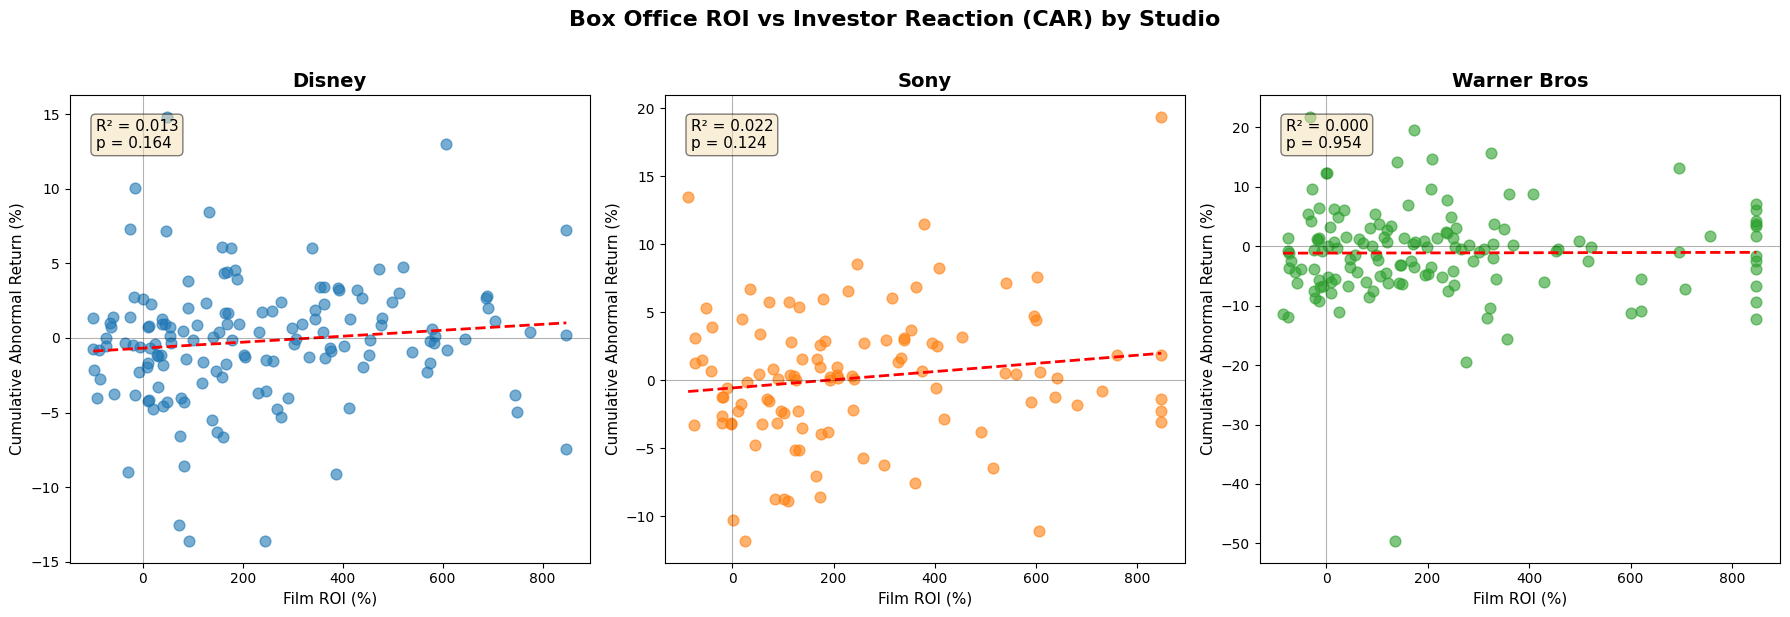

=== CORRELATION RESULTS ===

Disney:
  R-squared:   0.0131 — ROI explains 1.3% of CAR variance
  Correlation: 0.1146
  P-value:     0.1639 — not significant
  Slope:       0.001998 — for every 1% ROI increase, CAR changes by 0.0020%

Sony:
  R-squared:   0.0222 — ROI explains 2.2% of CAR variance
  Correlation: 0.1489
  P-value:     0.124 — not significant
  Slope:       0.003007 — for every 1% ROI increase, CAR changes by 0.0030%

Warner Bros:
  R-squared:   0.0 — ROI explains 0.0% of CAR variance
  Correlation: 0.005
  P-value:     0.9537 — not significant
  Slope:       0.000146 — for every 1% ROI increase, CAR changes by 0.0001%


In [ ]:
# BUSINESS QUESTION 1 — Does ROI predict CAR?

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Box Office ROI vs Investor Reaction (CAR) by Studio',
             fontsize=16, fontweight='bold', y=1.02)

studios = {'DIS': '#1f77b4', 'SONY': '#ff7f0e', 'WBD': '#2ca02c'}
studio_names = {'DIS': 'Disney', 'SONY': 'Sony', 'WBD': 'Warner Bros'}

correlations = {}

for idx, (ticker, color) in enumerate(studios.items()):
    studio_data = master_df[master_df['ticker'] == ticker].copy()

    ax = axes[idx]

    # Scatter plot
    ax.scatter(studio_data['ROI'],
               studio_data['car_total'],
               alpha=0.6, color=color, s=60)

    # Regression line
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        studio_data['ROI'],
        studio_data['car_total']
    )

    x_line = np.linspace(studio_data['ROI'].min(),
                          studio_data['ROI'].max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color='red', linewidth=2, linestyle='--')

    # Reference line at zero
    ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-', alpha=0.3)
    ax.axvline(x=0, color='black', linewidth=0.8, linestyle='-', alpha=0.3)

    # Labels
    ax.set_title(f'{studio_names[ticker]}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Film ROI (%)', fontsize=11)
    ax.set_ylabel('Cumulative Abnormal Return (%)', fontsize=11)
    ax.text(0.05, 0.95,
            f'R² = {r_value**2:.3f}\np = {p_value:.3f}',
            transform=ax.transAxes,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
            fontsize=11)

    correlations[ticker] = {
        'r_squared': round(r_value**2, 4),
        'p_value': round(p_value, 4),
        'slope': round(slope, 6),
        'correlation': round(r_value, 4)
    }

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/q1_roi_vs_car.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("=== CORRELATION RESULTS ===")
for ticker, stats_dict in correlations.items():
    print(f"\n{studio_names[ticker]}:")
    print(f"  R-squared:   {stats_dict['r_squared']} — ROI explains {stats_dict['r_squared']*100:.1f}% of CAR variance")
    print(f"  Correlation: {stats_dict['correlation']}")
    print(f"  P-value:     {stats_dict['p_value']} — {'STATISTICALLY SIGNIFICANT' if stats_dict['p_value'] < 0.05 else 'not significant'}")
    print(f"  Slope:       {stats_dict['slope']} — for every 1% ROI increase, CAR changes by {stats_dict['slope']:.4f}%")

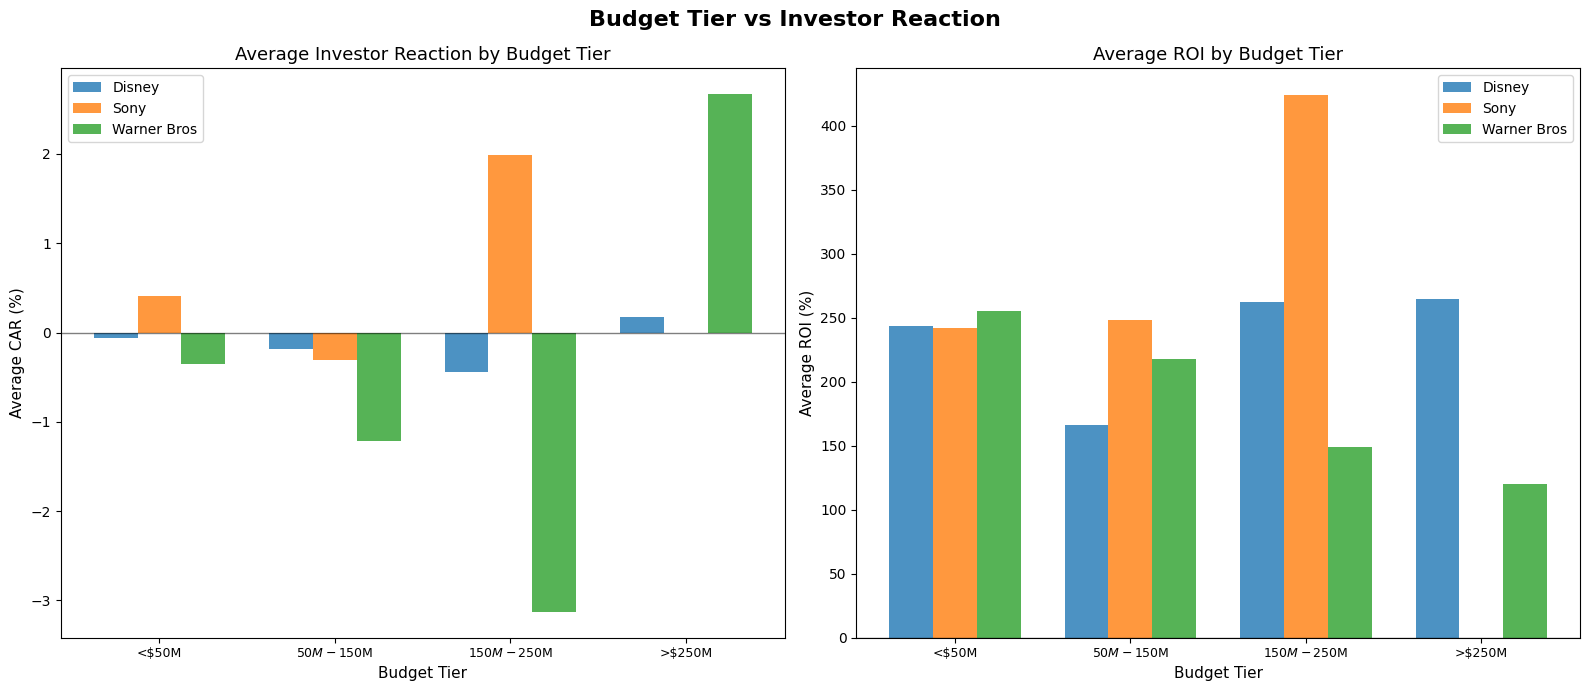

=== BUDGET TIER SUMMARY ===
                           film_count  avg_roi  avg_car  avg_car_day_of
budget_tier        ticker                                              
High ($150M-$250M) DIS             56   262.04    -0.44           -0.08
                   SONY             3   423.61     1.99           -0.44
                   WBD             27   148.93    -3.13           -0.29
Low (<$50M)        DIS             36   243.43    -0.06            0.29
                   SONY            67   241.84     0.40            0.10
                   WBD             72   254.95    -0.35           -0.47
Mega (>$250M)      DIS             10   264.96     0.18            0.48
                   WBD              1   120.44     2.67            3.26
Mid ($50M-$150M)   DIS             47   166.49    -0.18            0.16
                   SONY            38   248.07    -0.31           -0.05
                   WBD             40   217.69    -1.22            0.08


In [ ]:
# BUSINESS QUESTION 2 — Budget tier vs investor reaction

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Budget Tier vs Investor Reaction',
             fontsize=16, fontweight='bold')

tier_order = ['Low (<$50M)', 'Mid ($50M-$150M)',
              'High ($150M-$250M)', 'Mega (>$250M)']
tier_colors = ['#95a5a6', '#3498db', '#e67e22', '#e74c3c']

# Chart 1 — Average CAR by budget tier per studio
tier_car = master_df.groupby(['budget_tier', 'ticker'])['car_total'].mean().reset_index()

ax1 = axes[0]
x = np.arange(len(tier_order))
width = 0.25
studio_list = ['DIS', 'SONY', 'WBD']
studio_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, (studio, color) in enumerate(zip(studio_list, studio_colors)):
    studio_tier_data = []
    for tier in tier_order:
        val = tier_car[
            (tier_car['ticker'] == studio) &
            (tier_car['budget_tier'] == tier)
        ]['car_total'].values
        studio_tier_data.append(val[0] if len(val) > 0 else 0)

    bars = ax1.bar(x + i * width, studio_tier_data, width,
                   label=studio_names[studio], color=color, alpha=0.8)

ax1.set_xlabel('Budget Tier', fontsize=11)
ax1.set_ylabel('Average CAR (%)', fontsize=11)
ax1.set_title('Average Investor Reaction by Budget Tier', fontsize=13)
ax1.set_xticks(x + width)
ax1.set_xticklabels(['<$50M', '$50M-$150M', '$150M-$250M', '>$250M'],
                     fontsize=9)
ax1.axhline(y=0, color='black', linewidth=1, linestyle='-', alpha=0.5)
ax1.legend()

# Chart 2 — Average ROI by budget tier
tier_roi = master_df.groupby(['budget_tier', 'ticker'])['ROI'].mean().reset_index()

ax2 = axes[1]
for i, (studio, color) in enumerate(zip(studio_list, studio_colors)):
    studio_roi_data = []
    for tier in tier_order:
        val = tier_roi[
            (tier_roi['ticker'] == studio) &
            (tier_roi['budget_tier'] == tier)
        ]['ROI'].values
        studio_roi_data.append(val[0] if len(val) > 0 else 0)

    ax2.bar(x + i * width, studio_roi_data, width,
            label=studio_names[studio], color=color, alpha=0.8)

ax2.set_xlabel('Budget Tier', fontsize=11)
ax2.set_ylabel('Average ROI (%)', fontsize=11)
ax2.set_title('Average ROI by Budget Tier', fontsize=13)
ax2.set_xticks(x + width)
ax2.set_xticklabels(['<$50M', '$50M-$150M', '$150M-$250M', '>$250M'],
                     fontsize=9)
ax2.axhline(y=0, color='black', linewidth=1, linestyle='-', alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/q2_budget_tier_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print("=== BUDGET TIER SUMMARY ===")
summary = master_df.groupby(['budget_tier', 'ticker']).agg(
    film_count=('title', 'count'),
    avg_roi=('ROI', 'mean'),
    avg_car=('car_total', 'mean'),
    avg_car_day_of=('car_day_of_release', 'mean')
).round(2)
print(summary.to_string())

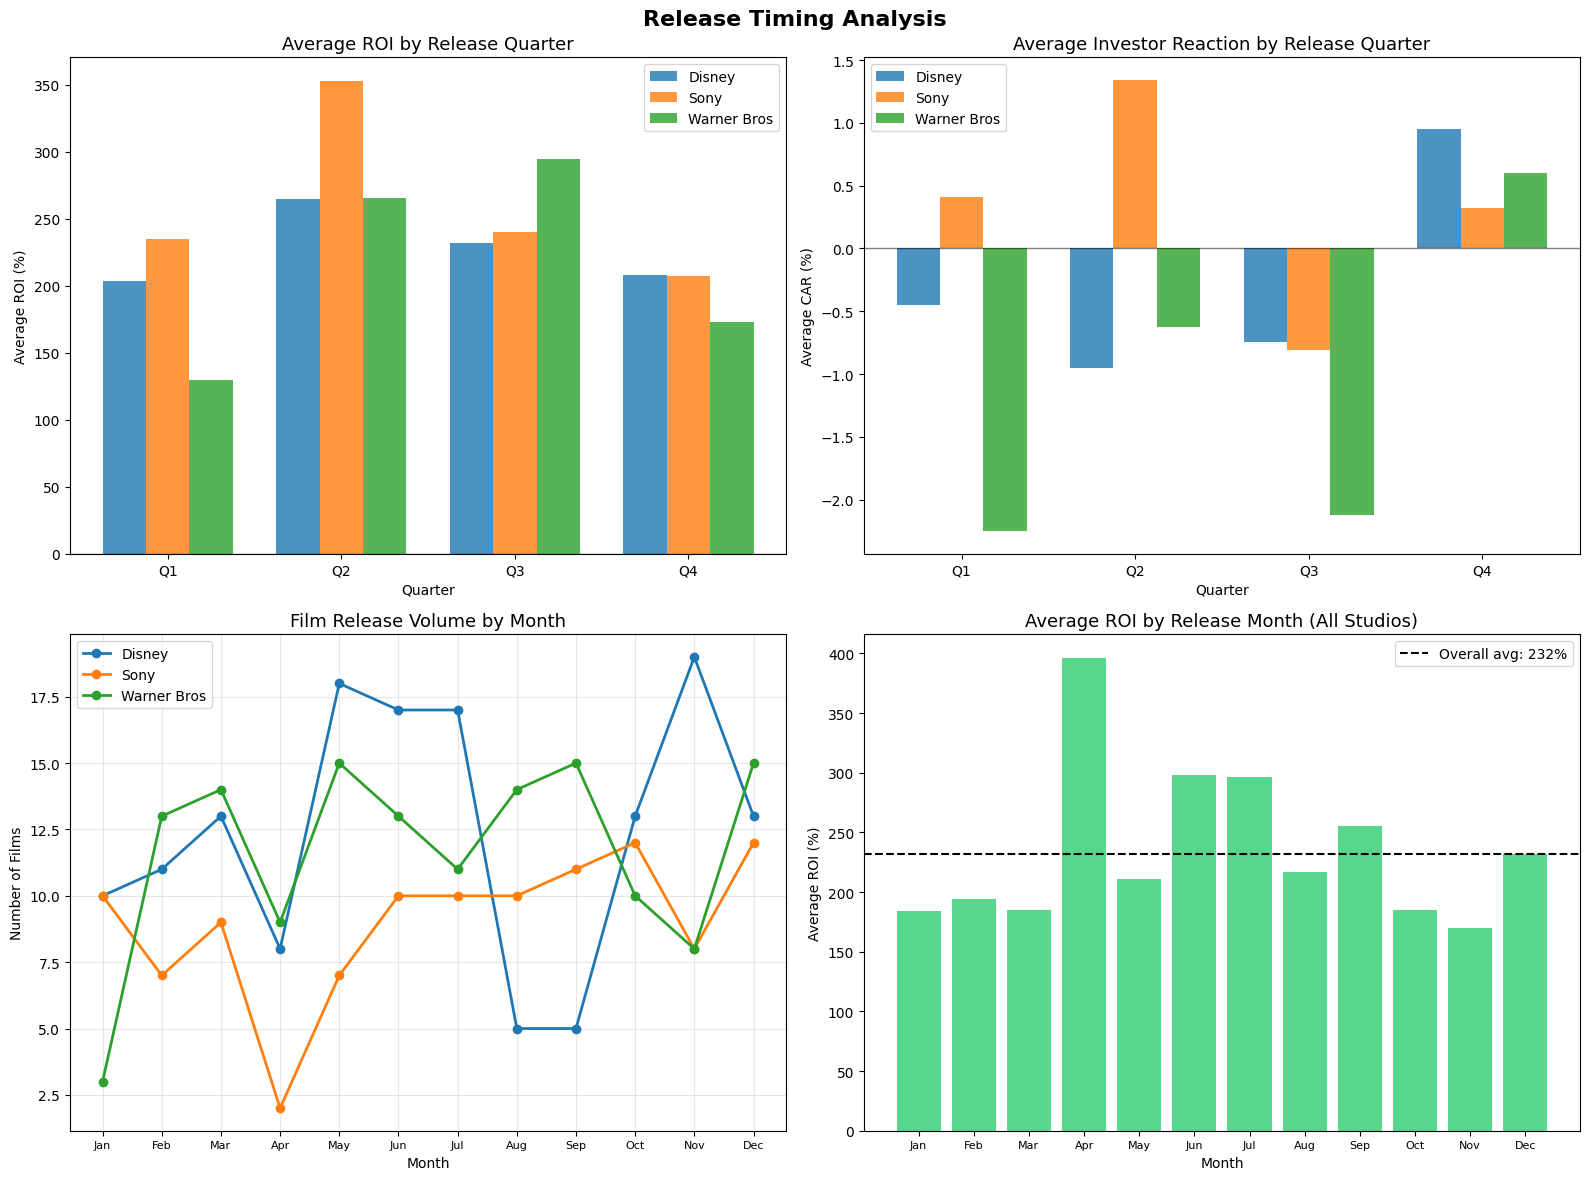

=== RELEASE TIMING SUMMARY ===
                 film_count  avg_roi  avg_car
release_quarter                              
1                        90   187.90    -0.80
2                        99   281.81    -0.39
3                        98   260.00    -1.33
4                       110   197.54     0.66


In [ ]:
# BUSINESS QUESTION 3 — Release timing vs performance

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Release Timing Analysis', fontsize=16, fontweight='bold')

# Chart 1 — Average ROI by quarter
quarter_roi = master_df.groupby(['release_quarter', 'ticker'])['ROI'].mean().reset_index()
quarter_names = {1: 'Q1\n(Jan-Mar)', 2: 'Q2\n(Apr-Jun)',
                 3: 'Q3\n(Jul-Sep)', 4: 'Q4\n(Oct-Dec)'}

ax1 = axes[0, 0]
x = np.arange(4)
for i, (studio, color) in enumerate(zip(studio_list, studio_colors)):
    roi_by_q = []
    for q in [1, 2, 3, 4]:
        val = quarter_roi[
            (quarter_roi['ticker'] == studio) &
            (quarter_roi['release_quarter'] == q)
        ]['ROI'].values
        roi_by_q.append(val[0] if len(val) > 0 else 0)
    ax1.bar(x + i * width, roi_by_q, width,
            label=studio_names[studio], color=color, alpha=0.8)

ax1.set_title('Average ROI by Release Quarter', fontsize=13)
ax1.set_xlabel('Quarter')
ax1.set_ylabel('Average ROI (%)')
ax1.set_xticks(x + width)
ax1.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
ax1.legend()
ax1.axhline(y=0, color='black', linewidth=1, alpha=0.5)

# Chart 2 — Average CAR by quarter
quarter_car = master_df.groupby(['release_quarter', 'ticker'])['car_total'].mean().reset_index()

ax2 = axes[0, 1]
for i, (studio, color) in enumerate(zip(studio_list, studio_colors)):
    car_by_q = []
    for q in [1, 2, 3, 4]:
        val = quarter_car[
            (quarter_car['ticker'] == studio) &
            (quarter_car['release_quarter'] == q)
        ]['car_total'].values
        car_by_q.append(val[0] if len(val) > 0 else 0)
    ax2.bar(x + i * width, car_by_q, width,
            label=studio_names[studio], color=color, alpha=0.8)

ax2.set_title('Average Investor Reaction by Release Quarter', fontsize=13)
ax2.set_xlabel('Quarter')
ax2.set_ylabel('Average CAR (%)')
ax2.set_xticks(x + width)
ax2.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
ax2.legend()
ax2.axhline(y=0, color='black', linewidth=1, alpha=0.5)

# Chart 3 — Film volume by month
ax3 = axes[1, 0]
for studio, color in zip(studio_list, studio_colors):
    monthly = master_df[master_df['ticker'] == studio].groupby(
        'release_month')['title'].count()
    ax3.plot(monthly.index, monthly.values,
             marker='o', label=studio_names[studio],
             color=color, linewidth=2)

ax3.set_title('Film Release Volume by Month', fontsize=13)
ax3.set_xlabel('Month')
ax3.set_ylabel('Number of Films')
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                      'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
                     fontsize=8)
ax3.legend()
ax3.grid(alpha=0.3)

# Chart 4 — Average ROI by month across all studios
ax4 = axes[1, 1]
monthly_roi = master_df.groupby('release_month')['ROI'].mean()
monthly_count = master_df.groupby('release_month')['title'].count()

bars = ax4.bar(monthly_roi.index, monthly_roi.values,
               color=['#e74c3c' if v < 100 else '#2ecc71'
                      for v in monthly_roi.values],
               alpha=0.8)
ax4.set_title('Average ROI by Release Month (All Studios)', fontsize=13)
ax4.set_xlabel('Month')
ax4.set_ylabel('Average ROI (%)')
ax4.set_xticks(range(1, 13))
ax4.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                      'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
                     fontsize=8)
ax4.axhline(y=master_df['ROI'].mean(), color='black',
            linewidth=1.5, linestyle='--',
            label=f'Overall avg: {master_df["ROI"].mean():.0f}%')
ax4.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/q3_release_timing.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("=== RELEASE TIMING SUMMARY ===")
timing_summary = master_df.groupby('release_quarter').agg(
    film_count=('title', 'count'),
    avg_roi=('ROI', 'mean'),
    avg_car=('car_total', 'mean'),
).round(2)
print(timing_summary)

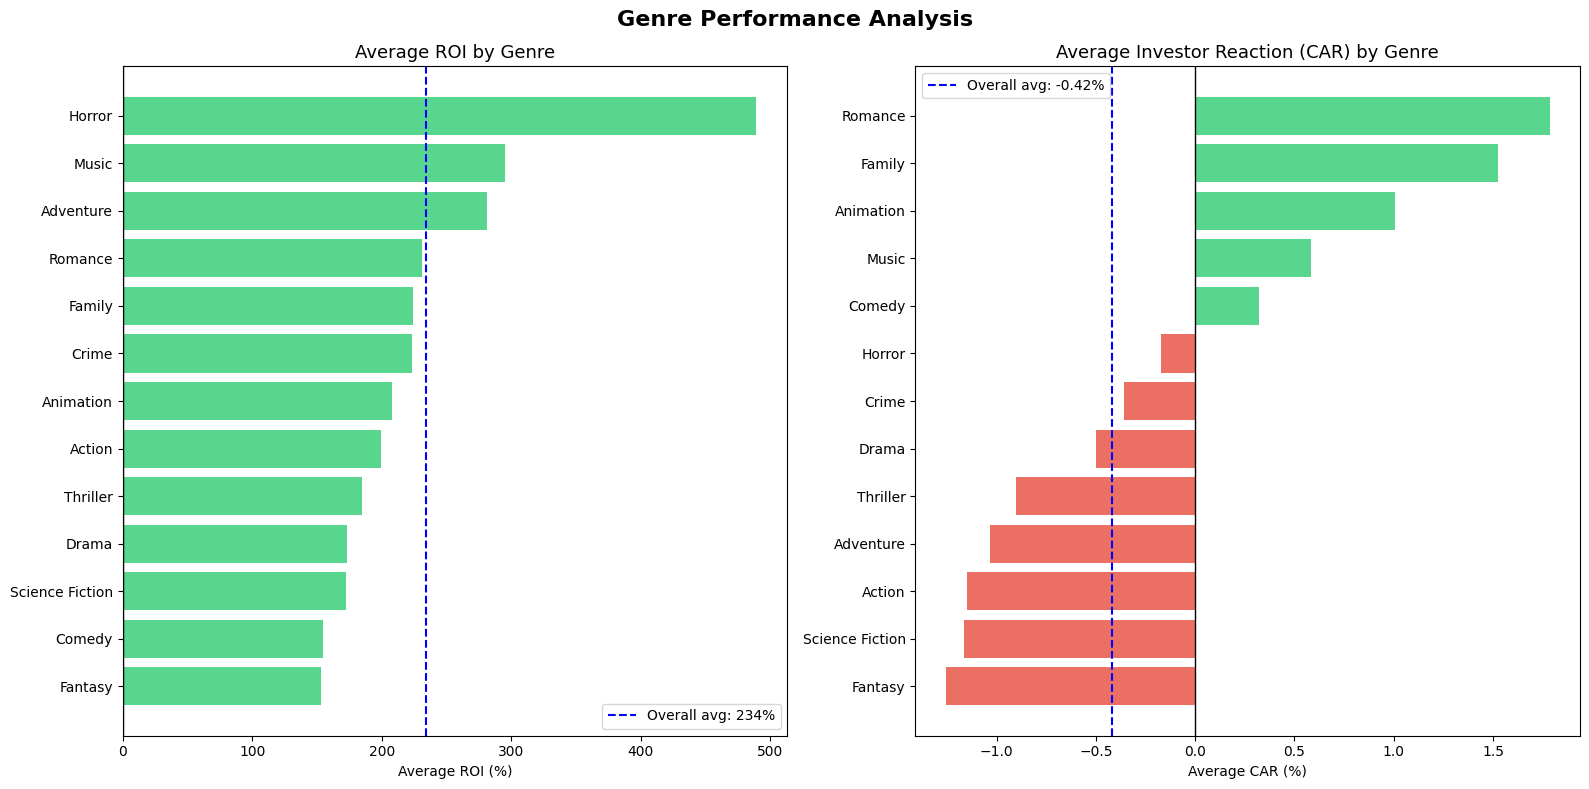

=== GENRE SUMMARY ===
                 film_count  avg_roi  median_roi  avg_car  avg_car_day_of
primary_genre                                                            
Horror                   45   488.95      453.74    -0.17            0.09
Music                     5   295.48      239.61     0.58            0.27
Adventure                42   281.22      210.05    -1.04           -0.21
Romance                   6   230.74      109.21     1.79            0.39
Family                   16   224.23      139.14     1.53            0.31
Crime                    14   223.66      244.08    -0.36            0.73
Animation                27   208.21      119.39     1.01            0.28
Action                  104   199.76      168.01    -1.15           -0.39
Thriller                  6   184.36      156.98    -0.90           -0.40
Drama                    36   172.81       95.93    -0.50            0.02
Science Fiction          25   172.22      147.71    -1.17            0.20
Comedy          

In [ ]:
# BUSINESS QUESTION 4 — Genre analysis

# Filter to genres with at least 5 films for statistical validity
genre_counts = master_df['primary_genre'].value_counts()
valid_genres = genre_counts[genre_counts >= 5].index

genre_data = master_df[master_df['primary_genre'].isin(valid_genres)]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Genre Performance Analysis', fontsize=16, fontweight='bold')

# Chart 1 — Average ROI by genre
genre_roi = genre_data.groupby('primary_genre')['ROI'].mean().sort_values(ascending=True)

ax1 = axes[0]
colors_roi = ['#e74c3c' if v < 0 else '#2ecc71' for v in genre_roi.values]
ax1.barh(genre_roi.index, genre_roi.values, color=colors_roi, alpha=0.8)
ax1.axvline(x=0, color='black', linewidth=1)
ax1.axvline(x=genre_data['ROI'].mean(), color='blue',
            linewidth=1.5, linestyle='--',
            label=f'Overall avg: {genre_data["ROI"].mean():.0f}%')
ax1.set_title('Average ROI by Genre', fontsize=13)
ax1.set_xlabel('Average ROI (%)')
ax1.legend()

# Chart 2 — Average CAR by genre
genre_car = genre_data.groupby('primary_genre')['car_total'].mean().sort_values(ascending=True)

ax2 = axes[1]
colors_car = ['#e74c3c' if v < 0 else '#2ecc71' for v in genre_car.values]
ax2.barh(genre_car.index, genre_car.values, color=colors_car, alpha=0.8)
ax2.axvline(x=0, color='black', linewidth=1)
ax2.axvline(x=genre_data['car_total'].mean(), color='blue',
            linewidth=1.5, linestyle='--',
            label=f'Overall avg: {genre_data["car_total"].mean():.2f}%')
ax2.set_title('Average Investor Reaction (CAR) by Genre', fontsize=13)
ax2.set_xlabel('Average CAR (%)')
ax2.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/q4_genre_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("=== GENRE SUMMARY ===")
genre_summary = genre_data.groupby('primary_genre').agg(
    film_count=('title', 'count'),
    avg_roi=('ROI', 'mean'),
    median_roi=('ROI', 'median'),
    avg_car=('car_total', 'mean'),
    avg_car_day_of=('car_day_of_release', 'mean')
).round(2).sort_values('avg_roi', ascending=False)
print(genre_summary.to_string())

=== BUILDING GREENLIGHT DECISION MODEL ===

Training samples: 397
Features: ['budget', 'release_quarter', 'ticker_encoded', 'genre_encoded', 'tier_encoded']

Training set: 317 films
Test set: 80 films

=== MODEL PERFORMANCE ===

Linear Regression:
  R-squared (test):     0.0313
  R-squared (CV mean):  -0.0550
  Mean Absolute Error:  3.7478%

Random Forest:
  R-squared (test):     -0.0569
  R-squared (CV mean):  -0.6588
  Mean Absolute Error:  4.1072%

=== FEATURE IMPORTANCE ===
What factors matter most for predicting investor reaction:
        feature  importance
         budget    0.569239
release_quarter    0.179828
  genre_encoded    0.150273
 ticker_encoded    0.087793
   tier_encoded    0.012867


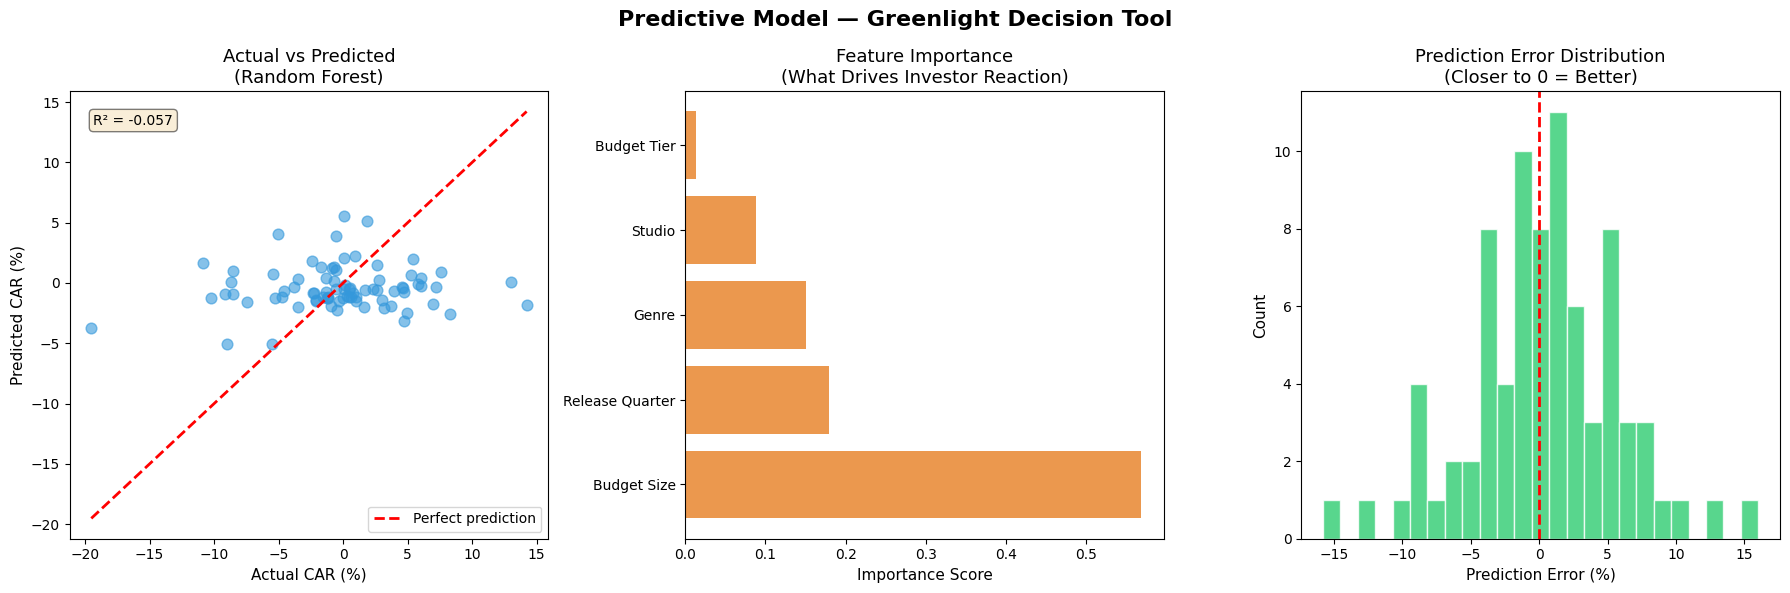


=== GREENLIGHT DECISION TOOL ===
Simulating investment decisions for hypothetical films:

Scenario                                 Studio       Budget   Q  Predicted CAR Tier                
----------------------------------------------------------------------------------------------------
Marvel sequel — Summer release           DIS    $250,000,000   2         -2.11% ✗ RECONSIDER
DC film — Summer release                 WBD    $200,000,000   3         -1.62% ✗ RECONSIDER
Horror film — Q4 release                 SONY   $20,000,000   4         +4.07% ✓ GREENLIGHT
Animated sequel — Holiday release        DIS    $150,000,000   4         +0.18% ✓ GREENLIGHT
Drama — Q1 release                       WBD    $80,000,000   1         -1.36% ✗ RECONSIDER
Comedy — Spring release                  SONY   $40,000,000   2         -0.44% ✗ RECONSIDER


In [ ]:
# PREDICTIVE MODEL — Can we predict investor reaction before a film releases?
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("=== BUILDING GREENLIGHT DECISION MODEL ===\n")

# Step 1 — Engineer your features
# These are variables a studio KNOWS before a film releases
model_df = master_df.copy()

# Encode categorical variables
le_ticker = LabelEncoder()
le_genre = LabelEncoder()
le_tier = LabelEncoder()

model_df['ticker_encoded'] = le_ticker.fit_transform(model_df['ticker'])
model_df['genre_encoded'] = le_genre.fit_transform(model_df['primary_genre'])
model_df['tier_encoded'] = le_tier.fit_transform(model_df['budget_tier'].astype(str))

# Features available BEFORE a film releases
feature_cols = [
    'budget',           # How much are we spending?
    'release_quarter',  # When are we releasing?
    'ticker_encoded',   # Which studio?
    'genre_encoded',    # What genre?
    'tier_encoded',     # What budget tier?
]

# Target — what we're trying to predict
target_col = 'car_total'

# Step 2 — Prepare data
X = model_df[feature_cols].dropna()
y = model_df.loc[X.index, target_col]

print(f"Training samples: {len(X)}")
print(f"Features: {feature_cols}\n")

# Step 3 — Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {len(X_train)} films")
print(f"Test set: {len(X_test)} films\n")

# Step 4 — Train two models and compare

# Model A — Linear Regression (simple, interpretable)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_r2 = r2_score(y_test, lr_pred)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_cv = cross_val_score(lr_model, X, y, cv=5, scoring='r2').mean()

# Model B — Random Forest (more powerful, captures non-linear patterns)
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_cv = cross_val_score(rf_model, X, y, cv=5, scoring='r2').mean()

print("=== MODEL PERFORMANCE ===")
print(f"\nLinear Regression:")
print(f"  R-squared (test):     {lr_r2:.4f}")
print(f"  R-squared (CV mean):  {lr_cv:.4f}")
print(f"  Mean Absolute Error:  {lr_mae:.4f}%")

print(f"\nRandom Forest:")
print(f"  R-squared (test):     {rf_r2:.4f}")
print(f"  R-squared (CV mean):  {rf_cv:.4f}")
print(f"  Mean Absolute Error:  {rf_mae:.4f}%")

# Step 5 — Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== FEATURE IMPORTANCE ===")
print("What factors matter most for predicting investor reaction:")
print(feature_importance.to_string(index=False))

# Step 6 — Visualize results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Predictive Model — Greenlight Decision Tool',
             fontsize=16, fontweight='bold')

# Chart 1 — Actual vs Predicted (Random Forest)
ax1 = axes[0]
ax1.scatter(y_test, rf_pred, alpha=0.6, color='#3498db', s=60)
ax1.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect prediction')
ax1.set_xlabel('Actual CAR (%)', fontsize=11)
ax1.set_ylabel('Predicted CAR (%)', fontsize=11)
ax1.set_title('Actual vs Predicted\n(Random Forest)', fontsize=13)
ax1.legend()
ax1.text(0.05, 0.95, f'R² = {rf_r2:.3f}',
         transform=ax1.transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Chart 2 — Feature Importance
ax2 = axes[1]
feature_labels = {
    'budget': 'Budget Size',
    'release_quarter': 'Release Quarter',
    'ticker_encoded': 'Studio',
    'genre_encoded': 'Genre',
    'tier_encoded': 'Budget Tier'
}
feature_importance['label'] = feature_importance['feature'].map(feature_labels)
ax2.barh(feature_importance['label'],
         feature_importance['importance'],
         color='#e67e22', alpha=0.8)
ax2.set_xlabel('Importance Score', fontsize=11)
ax2.set_title('Feature Importance\n(What Drives Investor Reaction)', fontsize=13)

# Chart 3 — Residuals distribution
ax3 = axes[2]
residuals = y_test - rf_pred
ax3.hist(residuals, bins=25, color='#2ecc71', alpha=0.8, edgecolor='white')
ax3.axvline(x=0, color='red', linewidth=2, linestyle='--')
ax3.set_xlabel('Prediction Error (%)', fontsize=11)
ax3.set_ylabel('Count', fontsize=11)
ax3.set_title('Prediction Error Distribution\n(Closer to 0 = Better)', fontsize=13)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/predictive_model.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Step 7 — Build the Greenlight Decision Tool
print("\n=== GREENLIGHT DECISION TOOL ===")
print("Simulating investment decisions for hypothetical films:\n")

def greenlight_predict(studio, genre, budget, quarter, model, encoders):
    """
    Given a proposed film's parameters, predict expected CAR
    This is the tool a Head of Production would use
    """
    ticker_enc = encoders['ticker'].transform([studio])[0]
    genre_enc = encoders['genre'].transform([genre])[0] if genre in encoders['genre'].classes_ else 0

    # Determine budget tier
    if budget < 50000000:
        tier = 'Low (<$50M)'
    elif budget < 150000000:
        tier = 'Mid ($50M-$150M)'
    elif budget < 250000000:
        tier = 'High ($150M-$250M)'
    else:
        tier = 'Mega (>$250M)'

    tier_enc = encoders['tier'].transform([tier])[0]

    features = [[budget, quarter, ticker_enc, genre_enc, tier_enc]]
    predicted_car = model.predict(features)[0]

    return predicted_car, tier

encoders = {
    'ticker': le_ticker,
    'genre': le_genre,
    'tier': le_tier
}

# Test scenarios — real business decisions
scenarios = [
    ('DIS', 'Action', 250000000, 2, 'Marvel sequel — Summer release'),
    ('WBD', 'Action', 200000000, 3, 'DC film — Summer release'),
    ('SONY', 'Horror', 20000000, 4, 'Horror film — Q4 release'),
    ('DIS', 'Animation', 150000000, 4, 'Animated sequel — Holiday release'),
    ('WBD', 'Drama', 80000000, 1, 'Drama — Q1 release'),
    ('SONY', 'Comedy', 40000000, 2, 'Comedy — Spring release'),
]

print(f"{'Scenario':<40} {'Studio':<6} {'Budget':>12} {'Q':>3} "
      f"{'Predicted CAR':>14} {'Tier':<20}")
print("-" * 100)

for studio, genre, budget, quarter, description in scenarios:
    pred_car, tier = greenlight_predict(
        studio, genre, budget, quarter, rf_model, encoders
    )
    signal = "✓ GREENLIGHT" if pred_car > 0 else "✗ RECONSIDER"
    print(f"{description:<40} {studio:<6} "
          f"${budget:>10,} {quarter:>3} "
          f"{pred_car:>+13.2f}% "
          f"{signal}")

In [ ]:
# DASHBOARD EXPORT — Format all data for Power BI and Tableau

print("Exporting all dashboard datasets...\n")

# Export 1 — Master dataset (main table for both tools)
master_df.to_csv('/content/drive/MyDrive/dashboard_master.csv', index=False)
print(f"✓ dashboard_master.csv — {len(master_df)} rows")

# Export 2 — Studio summary (KPI cards)
studio_summary = master_df.groupby('ticker').agg(
    total_films=('title', 'count'),
    avg_roi=('ROI', 'mean'),
    median_roi=('ROI', 'median'),
    avg_car_total=('car_total', 'mean'),
    avg_car_day_of=('car_day_of_release', 'mean'),
    avg_car_pre=('car_pre_release', 'mean'),
    avg_car_post=('car_post_release', 'mean'),
    total_budget=('budget', 'sum'),
    total_revenue=('revenue', 'sum'),
    avg_vote=('vote_average', 'mean'),
    pct_positive_car=('car_total', lambda x: (x > 0).mean() * 100)
).round(2).reset_index()

studio_summary['studio_name'] = studio_summary['ticker'].map({
    'DIS': 'Disney',
    'SONY': 'Sony',
    'WBD': 'Warner Bros'
})
studio_summary['total_roi'] = (
    (studio_summary['total_revenue'] - studio_summary['total_budget']) /
    studio_summary['total_budget'] * 100
).round(2)

studio_summary.to_csv('/content/drive/MyDrive/dashboard_studio_summary.csv',
                       index=False)
print(f"✓ dashboard_studio_summary.csv — {len(studio_summary)} rows")
print(studio_summary[['studio_name', 'total_films', 'avg_roi',
                        'avg_car_total', 'pct_positive_car']].to_string(index=False))

# Export 3 — Budget tier summary
tier_summary = master_df.groupby(['ticker', 'budget_tier']).agg(
    film_count=('title', 'count'),
    avg_roi=('ROI', 'mean'),
    median_roi=('ROI', 'median'),
    avg_car=('car_total', 'mean'),
    avg_budget=('budget', 'mean'),
    avg_revenue=('revenue', 'mean')
).round(2).reset_index()

tier_summary.to_csv('/content/drive/MyDrive/dashboard_budget_tiers.csv',
                     index=False)
print(f"\n✓ dashboard_budget_tiers.csv — {len(tier_summary)} rows")

# Export 4 — Genre summary
genre_summary = master_df.groupby(['ticker', 'primary_genre']).agg(
    film_count=('title', 'count'),
    avg_roi=('ROI', 'mean'),
    median_roi=('ROI', 'median'),
    avg_car=('car_total', 'mean'),
    avg_car_day_of=('car_day_of_release', 'mean')
).round(2).reset_index()

genre_summary.to_csv('/content/drive/MyDrive/dashboard_genres.csv',
                      index=False)
print(f"✓ dashboard_genres.csv — {len(genre_summary)} rows")

# Export 5 — Release timing summary
timing_summary = master_df.groupby(
    ['ticker', 'release_year', 'release_quarter']
).agg(
    film_count=('title', 'count'),
    avg_roi=('ROI', 'mean'),
    avg_car=('car_total', 'mean'),
    total_budget=('budget', 'sum'),
    total_revenue=('revenue', 'sum')
).round(2).reset_index()

timing_summary.to_csv('/content/drive/MyDrive/dashboard_timing.csv',
                       index=False)
print(f"✓ dashboard_timing.csv — {len(timing_summary)} rows")

# Export 6 — Stock prices for timeline chart
stocks_clean.to_csv('/content/drive/MyDrive/dashboard_stock_prices.csv')
print(f"✓ dashboard_stock_prices.csv — {len(stocks_clean)} rows")

# Export 7 — Annual performance summary
annual_summary = master_df.groupby(['ticker', 'release_year']).agg(
    film_count=('title', 'count'),
    avg_roi=('ROI', 'mean'),
    avg_car=('car_total', 'mean'),
    total_budget=('budget', 'sum'),
    total_revenue=('revenue', 'sum'),
    pct_profitable=('ROI', lambda x: (x > 0).mean() * 100)
).round(2).reset_index()

annual_summary['studio_name'] = annual_summary['ticker'].map({
    'DIS': 'Disney', 'SONY': 'Sony', 'WBD': 'Warner Bros'
})

annual_summary.to_csv('/content/drive/MyDrive/dashboard_annual.csv',
                       index=False)
print(f"✓ dashboard_annual.csv — {len(annual_summary)} rows")

# Export 8 — Top and bottom performers per studio
top_bottom = []
for ticker in ['DIS', 'SONY', 'WBD']:
    studio_data = master_df[master_df['ticker'] == ticker].copy()

    top5 = studio_data.nlargest(5, 'ROI')[
        ['title', 'ticker', 'release_date', 'budget',
         'revenue', 'ROI', 'car_total', 'primary_genre']
    ].copy()
    top5['rank_type'] = 'Top 5 ROI'

    bottom5 = studio_data.nsmallest(5, 'ROI')[
        ['title', 'ticker', 'release_date', 'budget',
         'revenue', 'ROI', 'car_total', 'primary_genre']
    ].copy()
    bottom5['rank_type'] = 'Bottom 5 ROI'

    top_bottom.append(top5)
    top_bottom.append(bottom5)

top_bottom_df = pd.concat(top_bottom)
top_bottom_df.to_csv('/content/drive/MyDrive/dashboard_top_bottom.csv',
                      index=False)
print(f"✓ dashboard_top_bottom.csv — {len(top_bottom_df)} rows")

print("\n=== ALL EXPORTS COMPLETE ===")
print("Files saved to Google Drive:")
files = [
    'dashboard_master.csv        — Every film with ROI and CAR',
    'dashboard_studio_summary.csv — KPI cards per studio',
    'dashboard_budget_tiers.csv   — Budget tier analysis',
    'dashboard_genres.csv         — Genre performance',
    'dashboard_timing.csv         — Release timing by year/quarter',
    'dashboard_stock_prices.csv   — Daily stock prices for timeline',
    'dashboard_annual.csv         — Year by year studio performance',
    'dashboard_top_bottom.csv     — Best and worst films per studio'
]
for f in files:
    print(f"  {f}")

Exporting all dashboard datasets...

✓ dashboard_master.csv — 397 rows
✓ dashboard_studio_summary.csv — 3 rows
studio_name  total_films  avg_roi  avg_car_total  pct_positive_car
     Disney          149   227.60          -0.22             47.65
       Sony          108   249.08           0.20             56.48
Warner Bros          140   222.90          -1.11             43.57

✓ dashboard_budget_tiers.csv — 11 rows
✓ dashboard_genres.csv — 42 rows
✓ dashboard_timing.csv — 114 rows
✓ dashboard_stock_prices.csv — 2515 rows
✓ dashboard_annual.csv — 30 rows
✓ dashboard_top_bottom.csv — 30 rows

=== ALL EXPORTS COMPLETE ===
Files saved to Google Drive:
  dashboard_master.csv        — Every film with ROI and CAR
  dashboard_studio_summary.csv — KPI cards per studio
  dashboard_budget_tiers.csv   — Budget tier analysis
  dashboard_genres.csv         — Genre performance
  dashboard_timing.csv         — Release timing by year/quarter
  dashboard_stock_prices.csv   — Daily stock prices for timel